In [ ]:
#importing libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [2]:
#data loading
dataset_path = "../Data/PetImages"
print(os.path.exists(dataset_path))

True


In [3]:
print(os.listdir(dataset_path))

['Cat', 'Dog']


In [4]:
cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

print(cat_path)
print(dog_path)

../Data/PetImages\Cat
../Data/PetImages\Dog


In [5]:
print("Cat Images:", len(os.listdir(cat_path)))
print("Dog Images:", len(os.listdir(dog_path)))

Cat Images: 12501
Dog Images: 12501


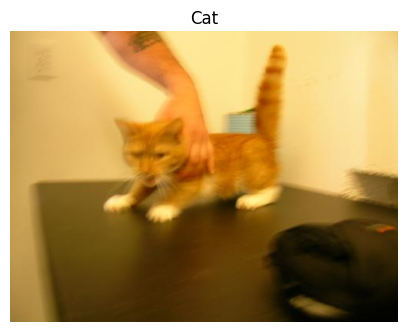

In [6]:
from PIL import Image

cat_image = os.path.join(
    cat_path,
    os.listdir(cat_path)[0]
)

img = Image.open(cat_image)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Cat")
plt.axis("off")
plt.show()

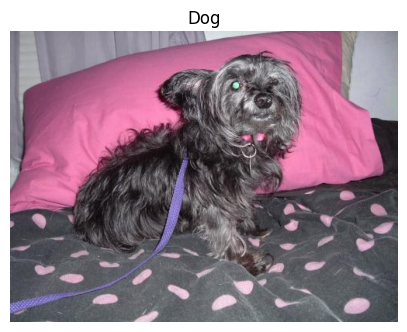

In [7]:
dog_image = os.path.join(
    dog_path,
    os.listdir(dog_path)[0]
)

img = Image.open(dog_image)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Dog")
plt.axis("off")
plt.show()

In [8]:
print(img.size)

(500, 375)


In [9]:
#removing corrupted images
from PIL import Image
import os

dataset_path = "../Data/PetImages"

bad_files = []

for folder in ["Cat", "Dog"]:

    folder_path = os.path.join(dataset_path, folder)

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        try:
            img = Image.open(file_path)
            img.verify()

        except Exception:
            bad_files.append(file_path)

print("Corrupted Images:", len(bad_files))

c:\Users\nukaa\Desktop\Image_Classifier_CNN\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Images: 4


In [10]:
print(bad_files[:20])

['../Data/PetImages\\Cat\\666.jpg', '../Data/PetImages\\Cat\\Thumbs.db', '../Data/PetImages\\Dog\\11702.jpg', '../Data/PetImages\\Dog\\Thumbs.db']


In [11]:
for file in bad_files:
    try:
        os.remove(file)
    except:
        pass

print("Corrupted images removed")

Corrupted images removed


In [12]:
print("Cat Images:",
      len(os.listdir(cat_path)))

print("Dog Images:",
      len(os.listdir(dog_path)))

Cat Images: 12499
Dog Images: 12499


In [ ]:
#Image preprocessing and normalisation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [14]:
#generate training
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 20000 images belonging to 2 classes.


In [15]:
#validation generator
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 4998 images belonging to 2 classes.


In [16]:
print(train_generator.class_indices)

{'Cat': 0, 'Dog': 1}


In [17]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 128, 128, 3)
(32,)


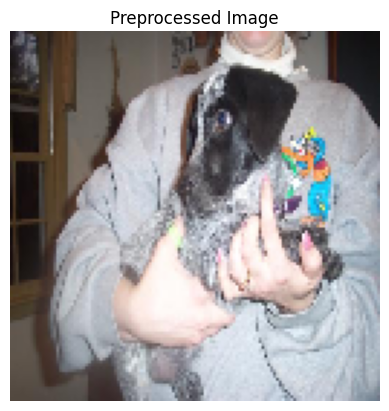

In [18]:
plt.imshow(images[0])
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [19]:
#building architechure

model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(128,128,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

c:\Users\nukaa\Desktop\Image_Classifier_CNN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#model training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 177ms/step - accuracy: 0.6531 - loss: 0.6103 - val_accuracy: 0.7231 - val_loss: 0.5480
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 194ms/step - accuracy: 0.7714 - loss: 0.4849 - val_accuracy: 0.8041 - val_loss: 0.4310
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 419ms/step - accuracy: 0.8215 - loss: 0.4033 - val_accuracy: 0.8175 - val_loss: 0.3999
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.8569 - loss: 0.3341 - val_accuracy: 0.8463 - val_loss: 0.3495
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.8809 - loss: 0.2838 - val_accuracy: 0.8535 - val_loss: 0.3363
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 203ms/step - accuracy: 0.9024 - loss: 0.2363 - val_accuracy: 0.8505 - val_loss: 0.3633
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.9250 - loss: 0.1824 - val_accuracy: 0.8627 - val_loss: 0.3631
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.9438 -

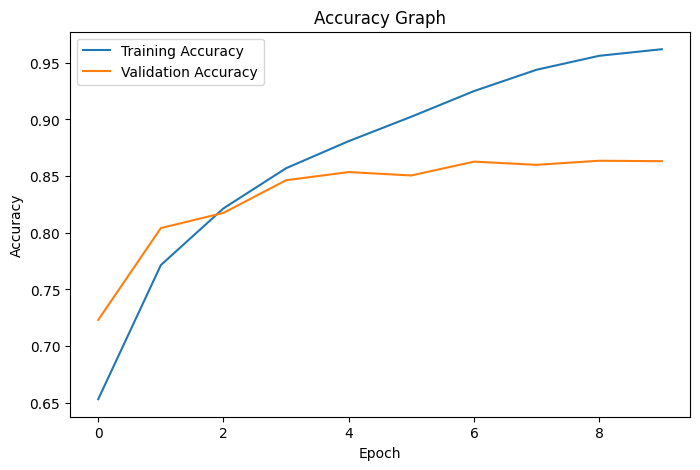

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

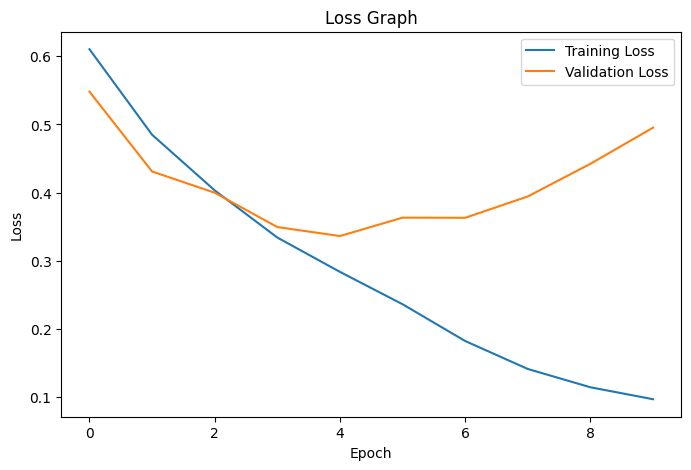

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [25]:
loss, accuracy = model.evaluate(
    validation_generator
)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 187ms/step - accuracy: 0.8631 - loss: 0.4953
Validation Loss: 0.4953007102012634
Validation Accuracy: 0.8631452322006226


In [ ]:
#model saving
model.save(
    "../Models/cat_dog_classifier.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


In [28]:
from tensorflow.keras.preprocessing import image

img_path = "../Data/PetImages/Cat/1.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[1.2746543e-07]]


In [29]:
if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

Cat 🐱
